In [1]:
import numpy
import matplotlib.pyplot as pyplot
import Spectra_Tools as ST
import arc
import scipy.constants as const
import os
import time
pyplot.rcParams.update(pyplot.rcParamsDefault) #reset matplotlib defaults as ARC overrides them!
atom = arc.Caesium()

# Using the `Spectra_Tools` module to simulate emission spectra

The module contains codes to enable simulation of emission spectra from an atomic ensemble in two ways, either through a Monte-Carlo simulation of decay from a target Rydberg state or by solving the rate equations to find the steady-state population and using this to build the emission spectrum.

This Notebook will give some examples of basic usage of both methods and comparisons between them.

### First Steps
The first time the code is run to simulate a specrum, look-up tables of transition rates and wavelengths for all levels will need to be calculated. The default is to do this for all transitions between states with $n\leq 80,\, \ell\leq 5$. This could take several minutes depending on the parameters and available computing power. By default any calculated LUTs will be saved to the current working directory. This can be turned off via the `save_LUTs` parameter. To see whather the code is calculating new LUTs and to monitor progress, set `printing = True`.

## Using the Rate Equation Method (`simulate_spectrum_re`)

In order to simulate the expected emission spectrum we need to specify the excitation pathway and the intensities of each of the driving fields, alongside the properties of the required output spectrum. To begin with we will keep things simple and assume a single-photon transition to a Rydberg state ($6S_{1/2} \rightarrow 14P_{3/2}$) with a very high driving intensity ($I = 100,000\times I_{\rm{sat}}$) to ensure a high percentage of population transfer to the Rydberg state. We will stick to the default values for the output spectrum: visible wavelengths (400nm to 750nm) with a 0.5nm resolution.

In [2]:
excitation_states = [(6,0,1/2), (14,1,3/2)] #(n,l,j) for each state in the excitation process
beam_intensities = [1e5] #in units of I_sat

In [3]:
spec_wvls, spec = ST.simulate_spectrum_re(excitation_states, beam_intensities, printing = True)

Using existing LUT of transition wavelengths. If you need to overwrite the existing file, set `recalculate_LUT=True` and run again.
Using existing LUT of transition rates. If you need to overwrite the existing file, set `recalculate_LUT=True` and run again.


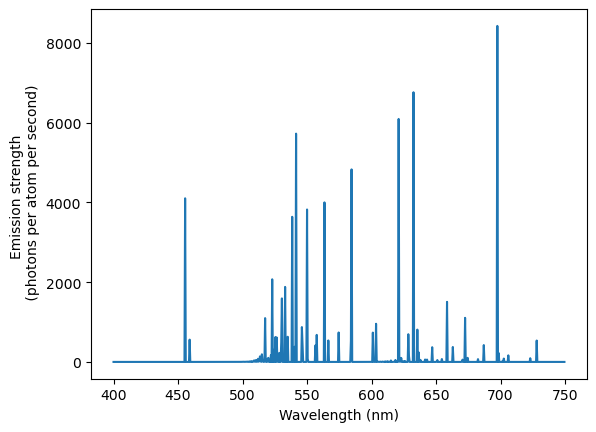

In [4]:
pyplot.figure()
pyplot.plot(spec_wvls, spec)
pyplot.xlabel('Wavelength (nm)')
pyplot.ylabel('Emission strength \n (photons per atom per second)')
pyplot.show()

We can include a wider range of wavelengths using the `spectrum_range` parameter to specify the lower and upper bounds of the simulated spectrum (in nm).

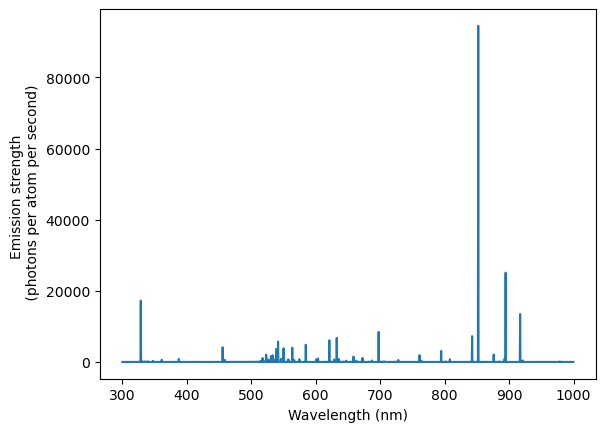

In [5]:
spec_wvls, spec = ST.simulate_spectrum_re(excitation_states, beam_intensities, spectrum_range = (300,1000))

pyplot.figure()
pyplot.plot(spec_wvls, spec)
pyplot.xlabel('Wavelength (nm)')
pyplot.ylabel('Emission strength \n (photons per atom per second)')
pyplot.show()

The time taken for this method scales linearly with the length of the specified output spectrum, which depends on both the `spectrum_range` and `spectrum_resolution` parameters.

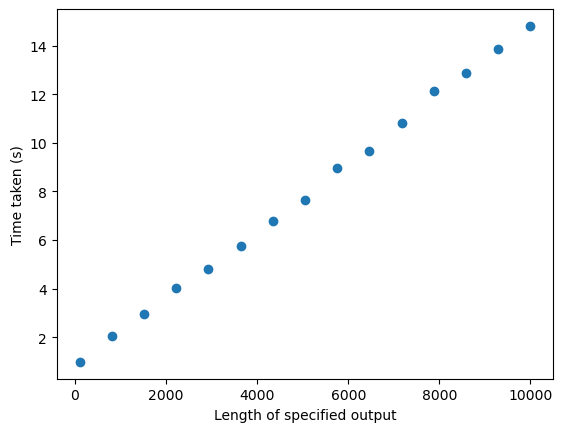

In [6]:
n_points = numpy.linspace(1e2, 1e4, 15)
times = numpy.zeros((len(n_points)))
spectrum_range = (200,2000)
for n in range(len(n_points)):
    spectrum_array = numpy.linspace(spectrum_range[0], spectrum_range[1], int(n_points[n]))
    spectrum_resolution = spectrum_array[1] - spectrum_array[0]
    start_time = time.time()
    wvls1, test1= ST.simulate_spectrum_re(excitation_states, beam_intensities, spectrum_range = spectrum_range, spectrum_resolution = spectrum_resolution)
    times[n] = time.time() - start_time

pyplot.figure()
pyplot.scatter(n_points, times)
pyplot.xlabel('Length of specified output')
pyplot.ylabel('Time taken (s)')
pyplot.show()

### State Populations (`steady_state_popn`)

It is also possible to extract the steady-state populations of each of the atomic levels by using the `steady_state_popn` function. 

We will demonstrate this by looking at the evolution of the population of the 'initial' and 'final' states in a two-level scheme and comparing them to the known evolution of population fractions for a 2-level atom (see for example Loudon's *The Quantum Theory of Light* equations 1.7.4) which are
$$
\begin{align}
N_g &= \frac{I_{\rm{sat}} + I}{2I + I_{\rm{sat}}}N = \frac{1 + \frac{I}{I_{\rm{sat}}}}{2\frac{I}{I_{\rm{sat}}} + 1}N\\
N_e &=\frac{I}{2I + I_{\rm{sat}}}N = \frac{\frac{I}{I_{\rm{sat}}}}{2\frac{I}{I_{\rm{sat}}} + 1}N
\end{align}$$

To show this, drive the $\rm{D_2}$ transition ($6S_{1/2} \rightarrow 6P_{3/2}$) with varying intensities.

In [7]:
excitation_states = [(6,0,1/2), (6,1,3/2)]
indices = [8,10] # the indices of the states in the excitation pathway (for clarity the search method is omitted)
beam_intensities = numpy.logspace(-6,8) #in units of I_sat

state_pops = numpy.zeros((2,len(beam_intensities)))
for i in range(len(beam_intensities)):
    all_states, Ns = ST.steady_state_popn(excitation_states, [beam_intensities[i]])
    for j in range(2):
        state_pops[j,i] = Ns[int(indices[j])]

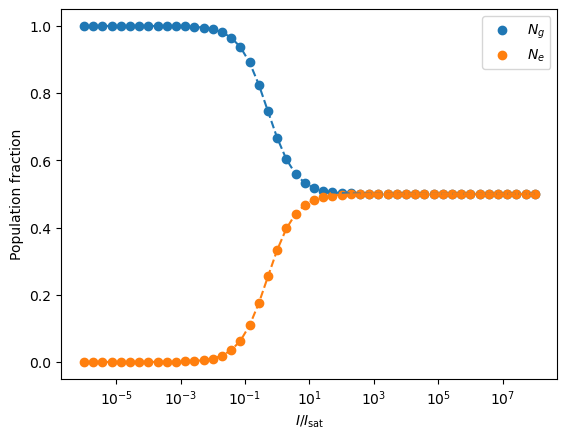

In [8]:
loudon_g = (1+beam_intensities)/(1+2*beam_intensities) #eqns 1.7.4
loudon_e = beam_intensities/(1+2*beam_intensities)

pyplot.figure()
pyplot.scatter(beam_intensities, state_pops[0,:], label = '$N_g$')
pyplot.scatter(beam_intensities, state_pops[1,:], label = '$N_e$')
pyplot.plot(beam_intensities, loudon_g, ls = 'dashed')
pyplot.plot(beam_intensities, loudon_e, ls = 'dashed')
pyplot.legend()
pyplot.xlabel('$I/I_{\\rm{sat}}$')
pyplot.ylabel('Population fraction')
pyplot.semilogx()
#pyplot.xlim(1e-2, 1e2)
pyplot.show()

Often the actual beam intensities are known in units of $\rm{Wm^{-2}}$ or $\rm{mW\,{cm}^{-2}}$. We can convert these to fractions of the saturation intensity $I_{\rm{sat}}$ for each transition by using the ARC `getSaturationIntensity` function.

In [9]:
excitation_states = [(6,0,1/2), (6,1,3/2), (7,0,1/2), (14,1,3/2), (13,2,5/2)]
beam_areas = numpy.array([numpy.pi*0.5e-3**2, numpy.pi*0.5e-3**2, numpy.pi*0.5e-3**3, numpy.pi*5e-3**2]) # in m^2
beam_powers = numpy.array([10e-3, 10e-3, 100e-3, 1e-3]) # in W
peak_intensities = 2*beam_powers/beam_areas # peak intensity in Wm^-2

In [11]:
Ispin = 7/2 # Nuclear spin of Cs
Isats = numpy.zeros(len(beam_powers))
for i in range(len(excitation_states)-1):
    (n1,l1,j1) = excitation_states[i]
    (n2,l2,j2) = excitation_states[i+1]
    # Find the saturation intensity of the `cycling` transition (between largest |F, mF> states)
    Isats[i] = atom.getSaturationIntensity(n1,l1,j1,Ispin+j1,Ispin+j1, n2,l2,j2,Ispin+j2, Ispin+j2) 

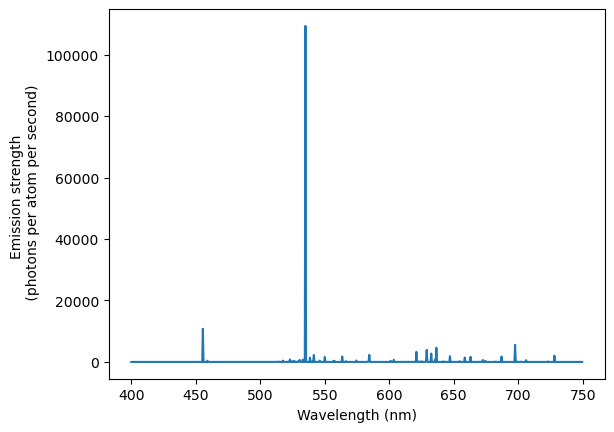

In [12]:
spec_wvls, spec = ST.simulate_spectrum_re(excitation_states, peak_intensities/Isats)

pyplot.figure()
pyplot.plot(spec_wvls, spec)
pyplot.xlabel('Wavelength (nm)')
pyplot.ylabel('Emission strength \n (photons per atom per second)')
pyplot.show()

## Using the Monte-Carlo Method (`simulate_spectrum_mc`)

To generate an emission spectrum using the Monte-Carlo method we simply need to specify the target Rydberg state that we are driving to. We'll use the $14P_{3/2}$ state again.

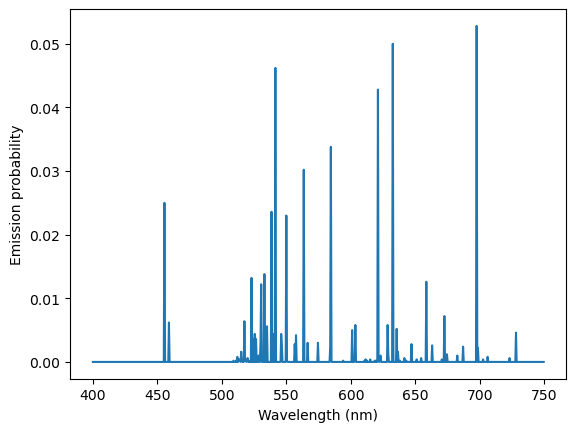

In [13]:
spec_wvls, spec = ST.simulate_spectrum_mc((14,1,3/2))

pyplot.figure()
pyplot.plot(spec_wvls, spec)
pyplot.xlabel('Wavelength (nm)')
pyplot.ylabel('Emission probability')
pyplot.show()

The parameters of the output spectrum can be changed in the same way as for the rate equation method, by specifying the `spectrum_range` and `spectrum_resolution` parameters.

The time taken for the Monte-Carlo method is *not* dependent on the size of the output spectrum, and is instead determined by the number of specified iterations. To guarantee convergence this number needs to be >1000 (the default is 5000), more iterations will generate a more precise result.

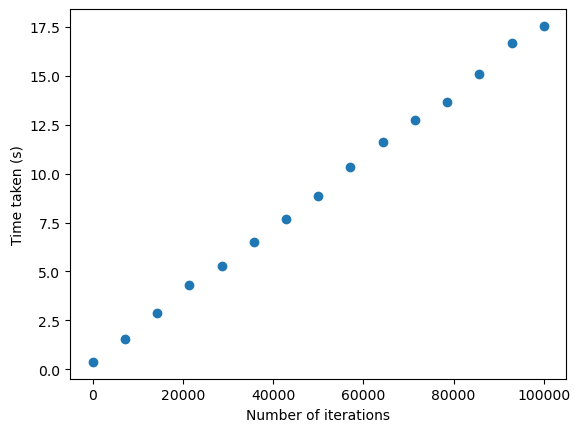

In [14]:
test_state = (12,2,5/2)
n_iters = numpy.linspace(1,1e5,15)
times = numpy.zeros(len(n_iters))
for i in range(len(n_iters)):
    start = time.time()
    wvls, spec = ST.simulate_spectrum_mc(test_state, iters = n_iters[i])
    times[i] = time.time() - start

pyplot.figure()
pyplot.scatter(n_iters, times)
pyplot.xlabel('Number of iterations')
pyplot.ylabel('Time taken (s)')
pyplot.show()

## Comparisons between methods

In general, for computing a spectrum with 0.5nm resolution in the visible (400 - 750 nm) range, the Monte-Carlo method is marginally faster than the rate equation method. However it is likely to be slightly less accurate as it does not consider emissions due to population accumulating in states other than the target state. Note that since the two methods output results in very different units, the spectra need to be normalised in order to be compared.

Time for rate equation method: 1.73s
Time for Monte Carlo method: 1.22s


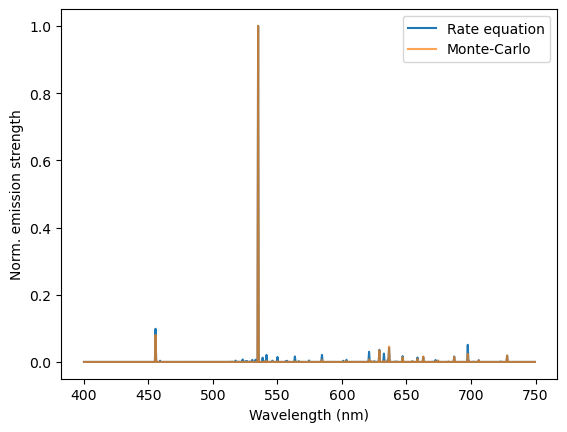

In [15]:
excitation_states = [(6,0,1/2), (6,1,3/2), (7,0,1/2), (14,1,3/2), (13,2,5/2)]
beam_intensities = [2e3, 6e3, 2e5, 2e6]
start_time = time.time()
wvls1, test1= ST.simulate_spectrum_re(excitation_states, beam_intensities)
time_1 = time.time()
wvls2, test2 = ST.simulate_spectrum_mc(excitation_states[-1])
time_2 = time.time()
print('Time for rate equation method: {:.2f}s'.format(time_1 - start_time))
print('Time for Monte Carlo method: {:.2f}s'.format(time_2 - time_1))

pyplot.figure()
pyplot.plot(wvls1, test1/numpy.max(test1), label = 'Rate equation')
pyplot.plot(wvls2, test2/numpy.max(test2), label = 'Monte-Carlo', alpha = 0.7)
pyplot.legend()
pyplot.xlabel('Wavelength (nm)')
pyplot.ylabel('Norm. emission strength')
pyplot.show()